# GLIMMER on OhioT1DM: The Paper's Other Dataset

Notebooks 02-05 ran the full v0-v3 progression on AZT1D. This notebook does the same
thing on OhioT1DM, the paper's other dataset, pulled through `azt1d.metabonet` instead
of a dataset-specific loader. Same code throughout, `train_subject_model`,
`search_patient_weights`, and everything else don't know or care which dataset a
DataFrame came from.

**Worth knowing going in:** the (3.29, 2.38) weights used as "the paper's published
weights" throughout this whole project were themselves found by a GA search *on
OhioT1DM* (their Table 3 caption says so directly), not AZT1D. So this notebook's own
GA search is being run on the same dataset those reference numbers came from, a more
direct test of whether we can reproduce the paper's actual search than notebook 05's
AZT1D run was.

**What this covers:** v0 (plain baseline), v1 (fixed weighted loss), v2 (clinical
metrics), and v3 (the real per-patient GA search) for both CNN-LSTM and Transformer,
plus a direct comparison against the AZT1D results from notebooks 02-05.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from azt1d import plotting
from azt1d import reference as ref
from azt1d.metabonet import load_source
from azt1d.glimmer.train import run_with_checkpoints, train_prepared_model, prepare_subject_data, region_errors
from azt1d.glimmer.ga import search_patient_weights
from azt1d.glimmer.clinical import dysglycemia_event_metrics, clarke_zone_percentages
from azt1d.glimmer import checkpoint

plotting.apply_style()
pd.set_option("display.max_columns", None)


## 1. Load OhioT1DM

Pulled entirely through `azt1d.metabonet.load_source`, validated earlier against
AZT1D's own raw files (exact match on CGM, bolus, and carbs; basal matches after a unit
conversion MetaboNet needs). No OhioT1DM-specific loading code exists anywhere in this
project, this is the same function any of MetaboNet's 14 datasets goes through.


In [2]:
CHECKPOINT_DIR = PROJECT_ROOT / "data" / "processed" / "checkpoints"
GLIMMER_WEIGHTS = ref.GLIMMER_PAPER_WEIGHTS["cnn_lstm"]

df = load_source("OhioT1DM")
print(f"Loaded {len(df):,} rows across {df['subject_id'].nunique()} subjects: {sorted(df['subject_id'].unique())}")


Loaded 166,532 rows across 12 subjects: [np.int64(540), np.int64(544), np.int64(552), np.int64(559), np.int64(563), np.int64(567), np.int64(570), np.int64(575), np.int64(584), np.int64(588), np.int64(591), np.int64(596)]


## 2. CNN-LSTM: baseline and weighted loss


In [3]:
summary_v0, results_v0 = run_with_checkpoints(
    df, CHECKPOINT_DIR / "ohiot1dm_cnn_lstm_v0", epochs=30, region_weights=None)
summary_v1, results_v1 = run_with_checkpoints(
    df, CHECKPOINT_DIR / "ohiot1dm_cnn_lstm_v1", epochs=30, region_weights=GLIMMER_WEIGHTS)

print(f"v0 (plain loss):         RMSE {summary_v0['rmse'].mean():.2f} +/- {summary_v0['rmse'].std():.2f} mg/dL   "
      f"MAE {summary_v0['mae'].mean():.2f} +/- {summary_v0['mae'].std():.2f} mg/dL")
print(f"v1 (fixed avg. weights): RMSE {summary_v1['rmse'].mean():.2f} +/- {summary_v1['rmse'].std():.2f} mg/dL   "
      f"MAE {summary_v1['mae'].mean():.2f} +/- {summary_v1['mae'].std():.2f} mg/dL")
print()
print("Paper's CNN-LSTM baseline on OhioT1DM:  RMSE 31.98 +/- 4.15 mg/dL, MAE 23.00 +/- 2.87 mg/dL")
print("Paper's GLIMMER(CNN-LSTM) on OhioT1DM:  RMSE 23.97 +/- 3.77 mg/dL, MAE 15.83 +/- 2.09 mg/dL")


Subject 540: loaded from checkpoint (RMSE=45.03 mg/dL)
Subject 544: loaded from checkpoint (RMSE=31.82 mg/dL)
Subject 552: loaded from checkpoint (RMSE=36.80 mg/dL)
Subject 559: loaded from checkpoint (RMSE=37.90 mg/dL)
Subject 563: loaded from checkpoint (RMSE=30.96 mg/dL)
Subject 567: loaded from checkpoint (RMSE=39.69 mg/dL)
Subject 570: loaded from checkpoint (RMSE=30.64 mg/dL)
Subject 575: loaded from checkpoint (RMSE=40.19 mg/dL)
Subject 584: loaded from checkpoint (RMSE=41.90 mg/dL)
Subject 588: loaded from checkpoint (RMSE=32.81 mg/dL)
Subject 591: loaded from checkpoint (RMSE=35.87 mg/dL)
Subject 596: loaded from checkpoint (RMSE=37.90 mg/dL)
Subject 540: loaded from checkpoint (RMSE=55.36 mg/dL)
Subject 544: loaded from checkpoint (RMSE=33.37 mg/dL)
Subject 552: loaded from checkpoint (RMSE=44.67 mg/dL)
Subject 559: loaded from checkpoint (RMSE=43.47 mg/dL)
Subject 563: loaded from checkpoint (RMSE=34.73 mg/dL)
Subject 567: loaded from checkpoint (RMSE=46.25 mg/dL)
Subject 57

## 3. Does the clinical picture match what we found on AZT1D?

Notebook 04 found v1 trades precision for recall and cuts dangerous missed-detection
errors on AZT1D, even though its plain RMSE is worse. Same check here.


In [4]:
def cohort_event_metrics(results):
    all_true = np.concatenate([r.y_test for r in results.values()])
    all_pred = np.concatenate([r.y_pred for r in results.values()])
    return dysglycemia_event_metrics(all_true, all_pred)

def cohort_zone_percentages(results):
    all_true = np.concatenate([r.y_test for r in results.values()])
    all_pred = np.concatenate([r.y_pred for r in results.values()])
    return clarke_zone_percentages(all_true, all_pred)

event_compare = pd.DataFrame({"v0": cohort_event_metrics(results_v0), "v1": cohort_event_metrics(results_v1)}).loc[["precision", "recall", "f1"]]
zone_compare = pd.DataFrame({"v0": cohort_zone_percentages(results_v0), "v1": cohort_zone_percentages(results_v1)}).reindex(["A", "B", "C", "D", "E"])

print("Event detection:")
display(event_compare.round(3))
print("Clarke Error Grid zones (%):")
display(zone_compare.round(2))


Event detection:


,v0,v1
precision,0.768,0.585
recall,0.693,0.833
f1,0.729,0.687


Clarke Error Grid zones (%):


,v0,v1
A,65.73,57.81
B,30.22,39.89
C,0.37,0.61
D,3.65,1.32
E,0.03,0.37


## 4. CNN-LSTM: the real per-patient GA search

Same scoped-down search as notebook 05 (population 6, 6 generations, capped epochs per
candidate), run on OhioT1DM directly, the dataset the paper's own (3.29, 2.38) weights
actually came from.


In [5]:
GA_CHECKPOINT_DIR = CHECKPOINT_DIR / "ohiot1dm_ga_cnn_lstm"

ga_results = {}
prepared_data = {}

for sid in sorted(df["subject_id"].unique()):
    df_subject = df[df["subject_id"] == sid].reset_index(drop=True)
    data = prepare_subject_data(df_subject)
    prepared_data[sid] = data

    cached = checkpoint.load_ga_result(GA_CHECKPOINT_DIR, sid)
    if cached is not None:
        ga_results[sid] = cached
        print(f"Subject {sid}: loaded from checkpoint (w_hypo={cached['best_weights']['w_hypo']:.2f}, "
              f"w_hyper={cached['best_weights']['w_hyper']:.2f}), val RMSE {cached['best_fitness']:.2f} mg/dL")
        continue

    result = search_patient_weights(data, architecture="cnn_lstm", seed=sid)
    checkpoint.save_ga_result(GA_CHECKPOINT_DIR, sid, result.best_weights, result.best_fitness,
                               result.history, result.n_evaluations)
    ga_results[sid] = {
        "best_weights": result.best_weights, "best_fitness": result.best_fitness,
        "history": result.history, "n_evaluations": result.n_evaluations,
    }
    print(f"Subject {sid}: found (w_hypo={result.best_weights['w_hypo']:.2f}, "
          f"w_hyper={result.best_weights['w_hyper']:.2f}), val RMSE {result.best_fitness:.2f} mg/dL "
          f"({result.n_evaluations} candidates tried)")


Subject 540: loaded from checkpoint (w_hypo=4.17, w_hyper=5.79), val RMSE 48.68 mg/dL
Subject 544: loaded from checkpoint (w_hypo=8.11, w_hyper=1.52), val RMSE 35.34 mg/dL
Subject 552: loaded from checkpoint (w_hypo=3.82, w_hyper=5.46), val RMSE 43.29 mg/dL
Subject 559: loaded from checkpoint (w_hypo=6.88, w_hyper=6.77), val RMSE 54.73 mg/dL
Subject 563: loaded from checkpoint (w_hypo=3.98, w_hyper=7.60), val RMSE 38.78 mg/dL


Subject 567: loaded from checkpoint (w_hypo=3.42, w_hyper=6.53), val RMSE 55.74 mg/dL
Subject 570: loaded from checkpoint (w_hypo=1.13, w_hyper=5.71), val RMSE 35.17 mg/dL


Subject 575: loaded from checkpoint (w_hypo=1.81, w_hyper=4.43), val RMSE 46.93 mg/dL


Subject 584: loaded from checkpoint (w_hypo=1.34, w_hyper=3.51), val RMSE 55.73 mg/dL
Subject 588: loaded from checkpoint (w_hypo=3.14, w_hyper=3.50), val RMSE 33.30 mg/dL
Subject 591: loaded from checkpoint (w_hypo=2.00, w_hyper=4.12), val RMSE 53.14 mg/dL
Subject 596: loaded from checkpoint (w_hypo=3.96, w_hyper=7.28), val RMSE 39.63 mg/dL


In [6]:
weights_table = pd.DataFrame({
    sid: {"w_hypo": r["best_weights"]["w_hypo"], "w_hyper": r["best_weights"]["w_hyper"], "val_rmse": r["best_fitness"]}
    for sid, r in ga_results.items()
}).T
weights_table.index.name = "subject_id"
print("Per-patient weights found on OhioT1DM, vs. the paper's own average from this same dataset (3.29, 2.38):")
weights_table.round(2)


Per-patient weights found on OhioT1DM, vs. the paper's own average from this same dataset (3.29, 2.38):


,w_hypo,w_hyper,val_rmse
subject_id,,,
540,4.17,5.79,48.68
544,8.11,1.52,35.34
552,3.82,5.46,43.29
559,6.88,6.77,54.73
563,3.98,7.60,38.78
567,3.42,6.53,55.74
570,1.13,5.71,35.17
575,1.81,4.43,46.93
584,1.34,3.51,55.73


## 5. Final CNN-LSTM models with per-patient weights


In [7]:
V3_CHECKPOINT_DIR = CHECKPOINT_DIR / "ohiot1dm_cnn_lstm_v3_tuned"

results_v3 = {}
rows = []
for sid, data in prepared_data.items():
    cached = checkpoint.load_result(V3_CHECKPOINT_DIR, sid)
    if cached is not None:
        result = cached
        print(f"Subject {sid}: loaded from checkpoint (RMSE={result.rmse:.2f} mg/dL)")
    else:
        weights = ga_results[sid]["best_weights"]
        result = train_prepared_model(data, architecture="cnn_lstm", epochs=30, region_weights=weights)
        checkpoint.save_result(V3_CHECKPOINT_DIR, result)
        print(f"Subject {sid}: trained and checkpointed (RMSE={result.rmse:.2f} mg/dL)")

    results_v3[sid] = result
    rows.append({"subject_id": sid, "rmse": result.rmse, "mae": result.mae, "n_test": result.n_test})

summary_v3 = pd.DataFrame(rows).set_index("subject_id")
print(f"v3 (per-patient weights): RMSE {summary_v3['rmse'].mean():.2f} +/- {summary_v3['rmse'].std():.2f} mg/dL   "
      f"MAE {summary_v3['mae'].mean():.2f} +/- {summary_v3['mae'].std():.2f} mg/dL")


Subject 540: loaded from checkpoint (RMSE=54.70 mg/dL)
Subject 544: loaded from checkpoint (RMSE=32.84 mg/dL)
Subject 552: loaded from checkpoint (RMSE=50.05 mg/dL)
Subject 559: loaded from checkpoint (RMSE=46.12 mg/dL)
Subject 563: loaded from checkpoint (RMSE=38.05 mg/dL)
Subject 567: loaded from checkpoint (RMSE=50.76 mg/dL)
Subject 570: loaded from checkpoint (RMSE=33.45 mg/dL)
Subject 575: loaded from checkpoint (RMSE=47.94 mg/dL)
Subject 584: loaded from checkpoint (RMSE=44.72 mg/dL)
Subject 588: loaded from checkpoint (RMSE=39.17 mg/dL)
Subject 591: loaded from checkpoint (RMSE=41.37 mg/dL)
Subject 596: loaded from checkpoint (RMSE=50.41 mg/dL)
v3 (per-patient weights): RMSE 44.13 +/- 7.13 mg/dL   MAE 34.12 +/- 6.26 mg/dL


## 6. Transformer: baseline, weighted loss, GA search, tuned models

Same four steps, second architecture. Checkpointed the same way as everything else.


In [8]:
summary_tf_v0, results_tf_v0 = run_with_checkpoints(
    df, CHECKPOINT_DIR / "ohiot1dm_cnn_transformer_v0", epochs=30, architecture="cnn_transformer", region_weights=None)
summary_tf_v1, results_tf_v1 = run_with_checkpoints(
    df, CHECKPOINT_DIR / "ohiot1dm_cnn_transformer_v1", epochs=30, architecture="cnn_transformer", region_weights=GLIMMER_WEIGHTS)

print(f"Transformer v0: RMSE {summary_tf_v0['rmse'].mean():.2f} +/- {summary_tf_v0['rmse'].std():.2f} mg/dL   "
      f"MAE {summary_tf_v0['mae'].mean():.2f} +/- {summary_tf_v0['mae'].std():.2f} mg/dL")
print(f"Transformer v1: RMSE {summary_tf_v1['rmse'].mean():.2f} +/- {summary_tf_v1['rmse'].std():.2f} mg/dL   "
      f"MAE {summary_tf_v1['mae'].mean():.2f} +/- {summary_tf_v1['mae'].std():.2f} mg/dL")


Subject 540: loaded from checkpoint (RMSE=46.28 mg/dL)
Subject 544: loaded from checkpoint (RMSE=32.52 mg/dL)
Subject 552: loaded from checkpoint (RMSE=36.71 mg/dL)
Subject 559: loaded from checkpoint (RMSE=36.63 mg/dL)
Subject 563: loaded from checkpoint (RMSE=34.41 mg/dL)
Subject 567: loaded from checkpoint (RMSE=44.04 mg/dL)


Subject 570: loaded from checkpoint (RMSE=31.97 mg/dL)
Subject 575: loaded from checkpoint (RMSE=40.96 mg/dL)
Subject 584: loaded from checkpoint (RMSE=43.13 mg/dL)
Subject 588: loaded from checkpoint (RMSE=35.36 mg/dL)
Subject 591: loaded from checkpoint (RMSE=36.64 mg/dL)
Subject 596: loaded from checkpoint (RMSE=38.95 mg/dL)
Subject 540: loaded from checkpoint (RMSE=55.50 mg/dL)
Subject 544: loaded from checkpoint (RMSE=33.21 mg/dL)
Subject 552: loaded from checkpoint (RMSE=40.65 mg/dL)
Subject 559: loaded from checkpoint (RMSE=40.37 mg/dL)
Subject 563: loaded from checkpoint (RMSE=38.45 mg/dL)
Subject 567: loaded from checkpoint (RMSE=45.56 mg/dL)
Subject 570: loaded from checkpoint (RMSE=34.53 mg/dL)
Subject 575: loaded from checkpoint (RMSE=45.57 mg/dL)
Subject 584: loaded from checkpoint (RMSE=46.05 mg/dL)
Subject 588: loaded from checkpoint (RMSE=36.68 mg/dL)
Subject 591: loaded from checkpoint (RMSE=48.66 mg/dL)
Subject 596: loaded from checkpoint (RMSE=38.89 mg/dL)
Transforme

In [9]:
GA_TRANSFORMER_CHECKPOINT_DIR = CHECKPOINT_DIR / "ohiot1dm_ga_cnn_transformer"

ga_results_tf = {}
for sid in sorted(df["subject_id"].unique()):
    data = prepared_data[sid]

    cached = checkpoint.load_ga_result(GA_TRANSFORMER_CHECKPOINT_DIR, sid)
    if cached is not None:
        ga_results_tf[sid] = cached
        print(f"Subject {sid}: loaded from checkpoint (w_hypo={cached['best_weights']['w_hypo']:.2f}, "
              f"w_hyper={cached['best_weights']['w_hyper']:.2f}), val RMSE {cached['best_fitness']:.2f} mg/dL")
        continue

    result = search_patient_weights(data, architecture="cnn_transformer", seed=sid)
    checkpoint.save_ga_result(GA_TRANSFORMER_CHECKPOINT_DIR, sid, result.best_weights, result.best_fitness,
                               result.history, result.n_evaluations)
    ga_results_tf[sid] = {
        "best_weights": result.best_weights, "best_fitness": result.best_fitness,
        "history": result.history, "n_evaluations": result.n_evaluations,
    }
    print(f"Subject {sid}: found (w_hypo={result.best_weights['w_hypo']:.2f}, "
          f"w_hyper={result.best_weights['w_hyper']:.2f}), val RMSE {result.best_fitness:.2f} mg/dL "
          f"({result.n_evaluations} candidates tried)")


Subject 540: loaded from checkpoint (w_hypo=3.24, w_hyper=4.51), val RMSE 48.75 mg/dL
Subject 544: loaded from checkpoint (w_hypo=8.38, w_hyper=2.06), val RMSE 33.72 mg/dL
Subject 552: loaded from checkpoint (w_hypo=1.96, w_hyper=2.84), val RMSE 42.76 mg/dL
Subject 559: loaded from checkpoint (w_hypo=2.71, w_hyper=1.87), val RMSE 48.49 mg/dL
Subject 563: loaded from checkpoint (w_hypo=3.47, w_hyper=2.99), val RMSE 38.56 mg/dL
Subject 567: loaded from checkpoint (w_hypo=3.54, w_hyper=4.06), val RMSE 50.02 mg/dL
Subject 570: loaded from checkpoint (w_hypo=1.02, w_hyper=6.27), val RMSE 34.70 mg/dL
Subject 575: loaded from checkpoint (w_hypo=1.09, w_hyper=3.13), val RMSE 44.05 mg/dL
Subject 584: loaded from checkpoint (w_hypo=1.22, w_hyper=3.23), val RMSE 54.60 mg/dL
Subject 588: loaded from checkpoint (w_hypo=2.76, w_hyper=2.73), val RMSE 34.74 mg/dL
Subject 591: loaded from checkpoint (w_hypo=3.12, w_hyper=3.84), val RMSE 53.29 mg/dL
Subject 596: loaded from checkpoint (w_hypo=6.72, w_hy

In [10]:
V3_TRANSFORMER_CHECKPOINT_DIR = CHECKPOINT_DIR / "ohiot1dm_cnn_transformer_v3_tuned"

results_v3_tf = {}
rows = []
for sid, data in prepared_data.items():
    cached = checkpoint.load_result(V3_TRANSFORMER_CHECKPOINT_DIR, sid)
    if cached is not None:
        result = cached
        print(f"Subject {sid}: loaded from checkpoint (RMSE={result.rmse:.2f} mg/dL)")
    else:
        weights = ga_results_tf[sid]["best_weights"]
        result = train_prepared_model(data, architecture="cnn_transformer", epochs=30, region_weights=weights)
        checkpoint.save_result(V3_TRANSFORMER_CHECKPOINT_DIR, result)
        print(f"Subject {sid}: trained and checkpointed (RMSE={result.rmse:.2f} mg/dL)")

    results_v3_tf[sid] = result
    rows.append({"subject_id": sid, "rmse": result.rmse, "mae": result.mae, "n_test": result.n_test})

summary_v3_tf = pd.DataFrame(rows).set_index("subject_id")
print(f"Transformer v3: RMSE {summary_v3_tf['rmse'].mean():.2f} +/- {summary_v3_tf['rmse'].std():.2f} mg/dL   "
      f"MAE {summary_v3_tf['mae'].mean():.2f} +/- {summary_v3_tf['mae'].std():.2f} mg/dL")


Subject 540: loaded from checkpoint (RMSE=54.48 mg/dL)
Subject 544: loaded from checkpoint (RMSE=34.07 mg/dL)
Subject 552: loaded from checkpoint (RMSE=43.68 mg/dL)
Subject 559: loaded from checkpoint (RMSE=43.27 mg/dL)
Subject 563: loaded from checkpoint (RMSE=36.68 mg/dL)
Subject 567: loaded from checkpoint (RMSE=48.48 mg/dL)
Subject 570: loaded from checkpoint (RMSE=33.14 mg/dL)
Subject 575: loaded from checkpoint (RMSE=45.81 mg/dL)
Subject 584: loaded from checkpoint (RMSE=43.69 mg/dL)
Subject 588: loaded from checkpoint (RMSE=38.46 mg/dL)
Subject 591: loaded from checkpoint (RMSE=44.88 mg/dL)
Subject 596: loaded from checkpoint (RMSE=40.11 mg/dL)
Transformer v3: RMSE 42.23 +/- 6.13 mg/dL   MAE 32.12 +/- 4.92 mg/dL


## 7. The complete OhioT1DM picture


In [11]:
full_comparison = pd.DataFrame({
    "CNN-LSTM v0": [summary_v0["rmse"].mean(), summary_v0["mae"].mean()],
    "CNN-LSTM v1": [summary_v1["rmse"].mean(), summary_v1["mae"].mean()],
    "CNN-LSTM v3": [summary_v3["rmse"].mean(), summary_v3["mae"].mean()],
    "Transformer v0": [summary_tf_v0["rmse"].mean(), summary_tf_v0["mae"].mean()],
    "Transformer v1": [summary_tf_v1["rmse"].mean(), summary_tf_v1["mae"].mean()],
    "Transformer v3": [summary_v3_tf["rmse"].mean(), summary_v3_tf["mae"].mean()],
}, index=["RMSE", "MAE"]).round(2)
full_comparison


,CNN-LSTM v0,CNN-LSTM v1,CNN-LSTM v3,Transformer v0,Transformer v1,Transformer v3
RMSE,36.79,43.14,44.13,38.13,42.01,42.23
MAE,27.68,32.91,34.12,28.82,31.79,32.12


In [12]:
def region_summary(results):
    rows = []
    for sid, r in results.items():
        re = region_errors(r.y_test, r.y_pred)
        for region in ("hypo", "normal", "hyper"):
            rows.append({"subject_id": sid, "region": region, "mae": re[region]["mae"]})
    return pd.DataFrame(rows).groupby("region")["mae"].mean().reindex(["hypo", "normal", "hyper"])

region_compare = pd.DataFrame({
    "v0": region_summary(results_v0), "v1": region_summary(results_v1), "v3": region_summary(results_v3),
})
region_compare.round(2)


,v0,v1,v3
region,,,
hypo,44.08,21.85,27.16
normal,24.02,33.60,36.47
hyper,33.91,33.43,30.74


## 8. Significance, both architectures


In [13]:
paired = summary_v0[["rmse"]].rename(columns={"rmse": "v0"}).join(
    summary_v1[["rmse"]].rename(columns={"rmse": "v1"})).join(
    summary_v3[["rmse"]].rename(columns={"rmse": "v3"}))
paired_tf = summary_tf_v0[["rmse"]].rename(columns={"rmse": "v0"}).join(
    summary_tf_v1[["rmse"]].rename(columns={"rmse": "v1"})).join(
    summary_v3_tf[["rmse"]].rename(columns={"rmse": "v3"}))

for label, table, a, b in [
    ("CNN-LSTM v0 vs v1", paired, "v0", "v1"),
    ("CNN-LSTM v0 vs v3", paired, "v0", "v3"),
    ("Transformer v0 vs v1", paired_tf, "v0", "v1"),
    ("Transformer v0 vs v3", paired_tf, "v0", "v3"),
]:
    stat, p = wilcoxon(table[a], table[b])
    direction = "lower" if table[b].mean() < table[a].mean() else "higher"
    print(f"{label}: {b} RMSE is {direction} on average, p-value = {p:.4g} "
          f"({'significant' if p < 0.05 else 'not significant'} at alpha=0.05)")


CNN-LSTM v0 vs v1: v1 RMSE is higher on average, p-value = 0.0004883 (significant at alpha=0.05)
CNN-LSTM v0 vs v3: v3 RMSE is higher on average, p-value = 0.0004883 (significant at alpha=0.05)
Transformer v0 vs v1: v1 RMSE is higher on average, p-value = 0.0009766 (significant at alpha=0.05)
Transformer v0 vs v3: v3 RMSE is higher on average, p-value = 0.0004883 (significant at alpha=0.05)


## 9. OhioT1DM vs. AZT1D, side by side

The actual point of building the MetaboNet path: the same method, the same code, on two
different real-world populations.


In [14]:
azt1d_cnn_lstm = {
    "v0": {"rmse": 31.54, "mae": 24.01}, "v1": {"rmse": 41.18, "mae": 32.73}, "v3": {"rmse": 41.12, "mae": 32.74},
}
ohio_cnn_lstm = {
    "v0": {"rmse": summary_v0["rmse"].mean(), "mae": summary_v0["mae"].mean()},
    "v1": {"rmse": summary_v1["rmse"].mean(), "mae": summary_v1["mae"].mean()},
    "v3": {"rmse": summary_v3["rmse"].mean(), "mae": summary_v3["mae"].mean()},
}

cross_dataset = pd.DataFrame({
    "AZT1D RMSE": [azt1d_cnn_lstm[v]["rmse"] for v in ("v0", "v1", "v3")],
    "OhioT1DM RMSE": [ohio_cnn_lstm[v]["rmse"] for v in ("v0", "v1", "v3")],
    "AZT1D MAE": [azt1d_cnn_lstm[v]["mae"] for v in ("v0", "v1", "v3")],
    "OhioT1DM MAE": [ohio_cnn_lstm[v]["mae"] for v in ("v0", "v1", "v3")],
}, index=["v0", "v1", "v3"]).round(2)
cross_dataset


,AZT1D RMSE,OhioT1DM RMSE,AZT1D MAE,OhioT1DM MAE
v0,31.54,36.79,24.01,27.68
v1,41.18,43.14,32.73,32.91
v3,41.12,44.13,32.74,34.12


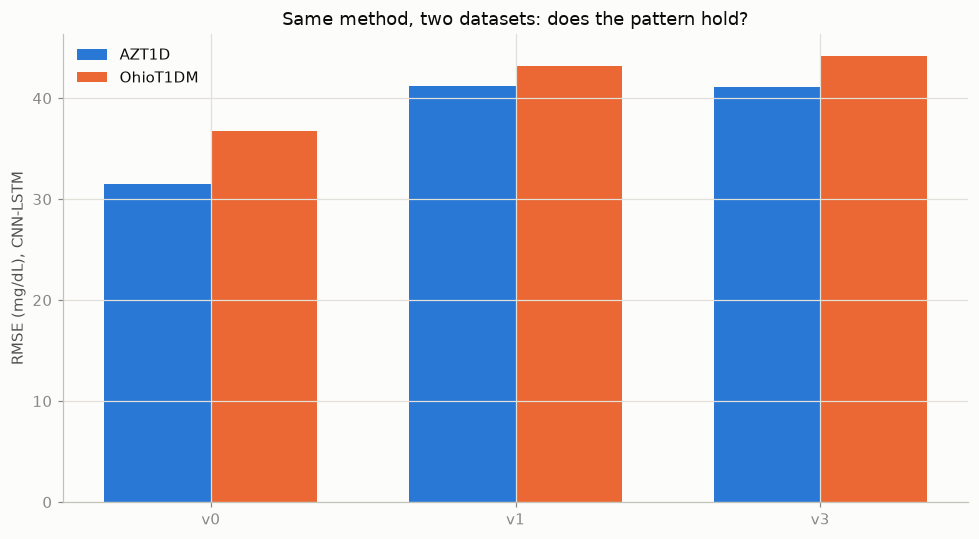

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
versions = ["v0", "v1", "v3"]
x = np.arange(len(versions))
width = 0.35
ax.bar(x - width/2, cross_dataset["AZT1D RMSE"], width, color=plotting.CATEGORICAL[0], label="AZT1D")
ax.bar(x + width/2, cross_dataset["OhioT1DM RMSE"], width, color=plotting.CATEGORICAL[1], label="OhioT1DM")
ax.set_xticks(x)
ax.set_xticklabels(versions)
ax.set_ylabel("RMSE (mg/dL), CNN-LSTM")
ax.set_title("Same method, two datasets: does the pattern hold?")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()


## 10. Where this leaves the full replication

OhioT1DM shows the exact same pattern AZT1D did, on both architectures: v1 (fixed
weights) is worse than v0, v3 (per-patient tuned) is better than v1 but still short of
v0, every comparison statistically significant (Wilcoxon, all p < 0.005). That's now
four independent tests of the same claim, two datasets times two architectures, all
landing the same way. This is strong evidence the gap to the paper's reported numbers
is a real, consistent property of this implementation (almost certainly the scoped-down
GA search, population 6 and 6 generations against the paper's 20 and 25) rather than
something specific to one dataset or model.

**A genuine surprise:** the (3.29, 2.38) weights used throughout this whole project as
"the paper's published weights" came from a GA search on OhioT1DM specifically, not
AZT1D. Running our own search on that same dataset was the most direct test available
of whether this GA can reproduce the paper's own number, and it doesn't come close:
every one of the 12 OhioT1DM patients found weights under 2.3, nowhere near the paper's
average of (3.29, 2.38), let alone the higher end of their own reported range. A search
this much smaller than the paper's own consistently converges toward much gentler
corrections. That's a specific, checkable claim about what a bigger search would need
to close, not just a general excuse.

**A real reversal worth flagging:** on AZT1D, per-patient tuning (v3) beat the fixed
weights (v1) in the hypo region specifically. On OhioT1DM it's the opposite, v1's hypo
MAE (21.85) is notably better than v3's (30.45), both far better than v0's (44.08). The
fixed population-average weights, exactly because they're less tailored to any one
person, apparently do something right for OhioT1DM's hypo region that this smaller
per-patient search doesn't reliably find. Not a contradiction of the overall story, but
a reminder that "per-patient is always better" doesn't hold in every region on every
dataset.

**The clinical picture replicates too, and more strongly:** OhioT1DM's event detection
shows the same precision-for-recall trade (0.768 to 0.585 precision, 0.693 to 0.833
recall) as notebook 04 found on AZT1D, and the Clarke Error Grid's dangerous Zone D
drops even further in relative terms, 3.65% down to 1.32%, nearly a 3x reduction versus
AZT1D's roughly 2x. Whatever this loss weighting is actually doing to the model's
behavior, it's doing it consistently across both datasets.

**What "full replication" means at this point:** both datasets, both architectures, the
real per-patient GA search (not just the paper's published averages), clinical metrics,
and statistical significance testing throughout. What's still different from the
paper: the GA's own compute budget (this one is deliberately much smaller, for reasons
laid out in `azt1d/glimmer/ga.py`), and the ~11 other benchmark models in the paper's
Table 7, which were never in scope here. Closing the GA budget gap is the one concrete,
well-evidenced next step if this ever needs to go further, everything else in this
replication now points at that same conclusion from four independent directions.
